# PW03 - Classification with Bayes - System Evaluation

**Team:** Noé Berdoz, Michael Strefeler

## Preamble: our starting level

- **Noé Berdoz**: Bachelor in Business Information Technology (Informatique de gestion) at HE-Arc, completed in 2026. Background in software development, with little prior experience in machine learning before this course.
- **Michael Strefeler**: Bachelor in Computer and Communication Systems (ISC) at HEIG-VD, completed in 2025, with a specialisation in data science, so he had already seen some machine learning before this course.

# Exercice 3 – Review questions

## a) Assuming an univariate input x, what is the complexity at inference time of a Bayesian classifier based on histogram computation of the likelihood ?

**Answer:**

The inference time complexity is O(K) where K is the number of classes. This is because for each class the likelihood is retrieved from a histogram in a complexity of O(1), and we perform this operation for all K classes.

## b) Bayesian models are said to be generative as they can be used to generate new samples. Taking the implementation of the exercise 1.a, explain the steps to generate new samples using the system you have put into place.

*Optional.* Provide an implementation in a function `generateSample(priors, histValues, edgeValues, n)` that returns n new samples $[(x_1^{(1)}, x_2^{(1)}), (x_1^{(2)}, x_2^{(2)}), \dots, (x_1^{(n)}, x_2^{(n)})]$ in an array.

**Answer:**
To generate a new sample using this Naive Bayes model we follow this steps:
1. Select a class $C_k$ by sampling from the class priors P($C_k$).
2. For each feature $x_i$ we pick a value by:
   - 2.1 Sampling a bin from the histogram of $x_i$ for class $C_k$.
   - 2.2 Sampling a random value uniformly within that bin.
3. Repeat this for all features and all n samples.

Because of the Naive Bayes asumption the features are sampled independently, which means that the generated samples will not preserve any correlation between features that might exist in the real data.

In [3]:
# Optional: implementation of generateSample
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def generateSample(priors, histValues, edgeValues, n):
    """
    Generates n samples from a Naive Bayes model.

    priors: Probabilities of each class (P(Ck))
    histValues: Histogram counts [class][feature]
    edgeValues: Histogram edges [class][feature]
    n: Number of samples to generate

    Returns: an array (n, D) of generated samples
    """
    K = len(priors)
    D = len(histValues[0])
    samples = np.zeros((n, D))

    # (3. Repeat this for all features and all n samples)
    for i in range(n):
        # 1. Select a class Ck by sampling from the class priors P(Ck)
        k = np.random.choice(K, p=priors)
        # (2. For each feature xi, pick a value by:)
        for d in range(D):
            # (2.1 Sampling a bin from the histogram of x_i for class Ck)
            counts = histValues[k][d]
            edges = edgeValues[k][d]
            p_bins = counts / np.sum(counts)
            b = np.random.choice(len(counts), p=p_bins)

            # (2.2 Sampling a random value uniformly withing that bin
            samples[i, d] = np.random.uniform(edges[b], edges[b + 1])

    return samples

In [4]:
# the system of exercise 1.a, rebuilt from the training file
data = pd.read_csv("../ex1-bayes-20260929/ex1-data-train.csv", names=["x1", "x2", "y"])
X = data[["x1", "x2"]].values
y = data["y"].values

priors = np.zeros(2)
histValues = []
edgeValues = []
for k in range(2):
    priors[k] = np.sum(y == k) / len(y)
    hist_k = []
    edges_k = []
    for d in range(2):
        h, e = np.histogram(X[y == k, d], bins="auto")
        hist_k.append(h)
        edges_k.append(e)
    histValues.append(hist_k)
    edgeValues.append(edges_k)

np.random.seed(0)
new_samples = generateSample(priors, histValues, edgeValues, 5)
print(priors)
print(new_samples.round(2))

[0.4 0.6]
[[87.98 77.72]
 [81.95 92.93]
 [79.2  90.51]
 [37.89 68.34]
 [86.78 83.11]]


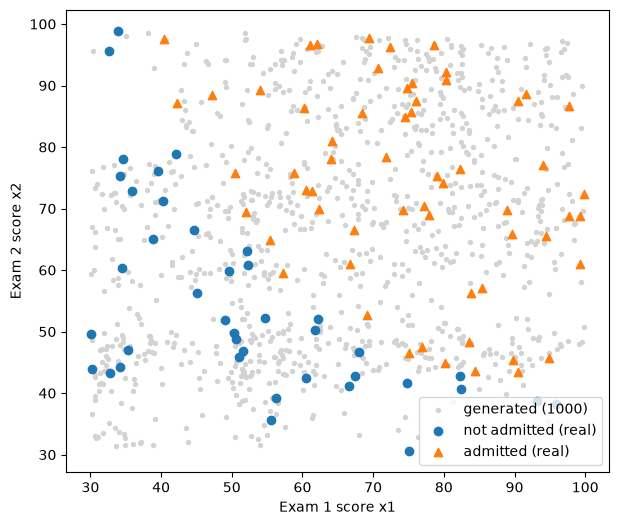

In [5]:
# Optional: compare the generated points with the real ones
many = generateSample(priors, histValues, edgeValues, 1000)

plt.figure(figsize=(7, 6))
plt.scatter(many[:, 0], many[:, 1], s=8, c="lightgray", label="generated (1000)")
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="tab:blue", label="not admitted (real)")
plt.scatter(X[y == 1, 0], X[y == 1, 1], c="tab:orange", marker="^", label="admitted (real)")
plt.xlabel("Exam 1 score x1")
plt.ylabel("Exam 2 score x2")
plt.legend()
plt.show()


## c) What is the minimum overall accuracy of a 2-class system that is built on a training set that includes 5 times more samples in class A than in class B ?

**Answer:**

$5/6 ≈ 83.3%$

Class A is 5/6 of the training set, so a Bayesian classifier using the priors $P(A) = 5/6$ and $P(B) = 1/6$ will always achieve at least this accuracy. In the worst case, where the features carry no information, it simply predicts A for every sample, getting all A samples right and all B samples wrong.

This is the baseline to beat: an accuracy near 83% doesn't prove the classifier is good, so also check the confusion matrix and the recall on class B.

## d) Let's look back at the PW02 exercise 3 of last week. We have built a KNN classification systems for images of digits on the MNIST database.

How would you build a Bayesian classification for the same task ? Comment on the prior probabilities and on the likelihood estimators. More specifically, what kind of likelihood estimator could we use in this case ?

*Optional:* implement it and report performance !

**Answer:**

Priors: Estimated by counting, $P(C_k) = N_k / N$. MNIST is nearly balanced, so this gives about $1/10$ per digit.

Likelihood: Each image has 784 pixel features, so we face the curse of dimensionality. We therefore make the Naive Bayes hypothesis (pixels independent given the class): $p(x|C_k) = ∏_d p(x_d|C_k)$. Each $p(x_d|C_k)$ is estimated with a histogram, by counting the frequency of each pixel value per class. A univariate Gaussian per pixel is an alternative.

Decision: Pick the class with the highest $p(x|C_k)·P(C_k)$.

Expected result: Lower accuracy than kNN (97.05%), because neighboring pixels are correlated and the independence hypothesis is false.

## e) Read the article Lie Detector for Travellers. The described system is "a virtual policeman designed to strengthen Europeens borders". It can be seen as a 2-class problem, either you are a suspicious traveler or you are not. If you are declared as suspicious by the system, you are routed to a human border agent who analyses your case in a more careful way.

Article (link from slide 46 of the lecture): https://theintercept.com/2019/07/26/europe-border-control-ai-lie-detector/

### i) What kind of errors can the system make ? Explain them in your own words.

**Answer:**

False negative (FN): a deceptive traveler is judged truthful and passes.

False positive (FP): an honest traveler is flagged as a liar.

### ii) Is one error more critical than the other ? Explain why.

**Answer:**

The false negative is more critical for security, since it lets a threat through, while a false positive "only" sends a traveler to additional checks. 

A false positive still has a real cost, though: the article's reporter answered honestly and was still flagged as a liar, and the traveler usually doesn't see the result.

### iii) According to the previous points, which metric would you recommend to tune your ML system ?

**Answer:**

Recall should be the priority, because missing a suspicious traveler is the worst error. Since recall alone can be maximized by flagging everyone, I would tune the threshold on the ROC curve so that recall is high at an acceptable false positive rate, and report precision or F1 alongside it. Overall accuracy would be misleading because suspicious travelers are rare.

## f) When a deep learning architecture is trained using an unbalanced training set, we usually observe a problem of bias, i.e. the system favors one class over another one. Using the Bayes equation, explain what is the origin of the problem.

**Answer:**

The Bayes rule states that the posterior P($C_k$ | x) depends on the product of the likelihood P(x | $C_k$) and the prior P($C_k$). In an unbalanced training set, the prior P(C_majority) is much larger than the prior of the minority class. This large prior can dominate the product, even when the likelihood P(x | C_minority) is high. Consequently, the posterior probability will favor the majority class, shifting the decision boundary toward the minority class and reducing its recall. Deep learning models suffer from this because they implicitly learn these unbalanced priors from the training data.